# HR Analytics: Employee Attrition
### Predicting employee resignation risk & uncovering key drivers of attrition

**Domain:** Human Resources
**Skills demonstrated:** Data Cleaning, Feature Engineering, Exploratory Data Analysis / Visualization, Classification Modeling, Business Insight Generation

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 employees, 35 attributes) — a widely used, publicly available fictional HR dataset created by IBM data scientists.

**Goal:**
1. Understand *why* employees leave (EDA + HR metrics dashboard)
2. Build a simple, explainable model to *predict who might leave*
3. Translate findings into strategic HR recommendations

---
**Approach note:** This project intentionally uses simple, explainable techniques (Logistic Regression as the primary model) rather than deep learning or heavily tuned ensembles. For an HR use case, an interpretable model that HR teams can trust and act on is more valuable than a marginally more accurate black box.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


**Quick data check** — this dataset is known to be clean (no missing values), but we verify rather than assume.

In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.info()

Missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel       

## 2. Key HR Metrics Dashboard

Before modeling, we build the visual dashboard HR would actually look at. Each chart answers one specific business question.


In [4]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100
print(f"Overall attrition rate: {attrition_rate:.1f}%")
print(f"Employees who left: {(df['Attrition']=='Yes').sum()} out of {len(df)}")

Overall attrition rate: 16.1%
Employees who left: 237 out of 1470


### 2.1 Overall Attrition Split

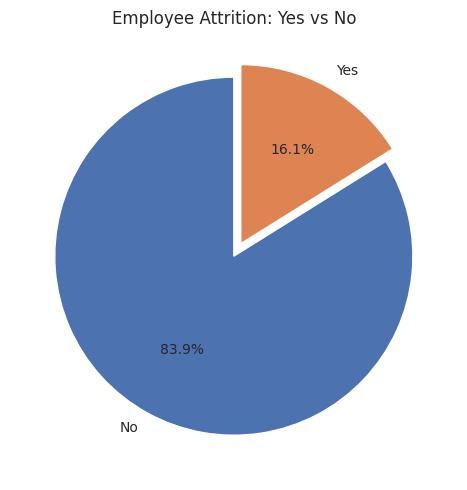

In [5]:
fig, ax = plt.subplots(figsize=(5,5))
counts = df["Attrition"].value_counts()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
       colors=["#4C72B0", "#DD8452"], explode=(0, 0.08))
ax.set_title("Employee Attrition: Yes vs No")
plt.tight_layout()
plt.savefig("charts/01_attrition_overall.png", dpi=120)
plt.show()

### 2.2 Attrition Rate by Department

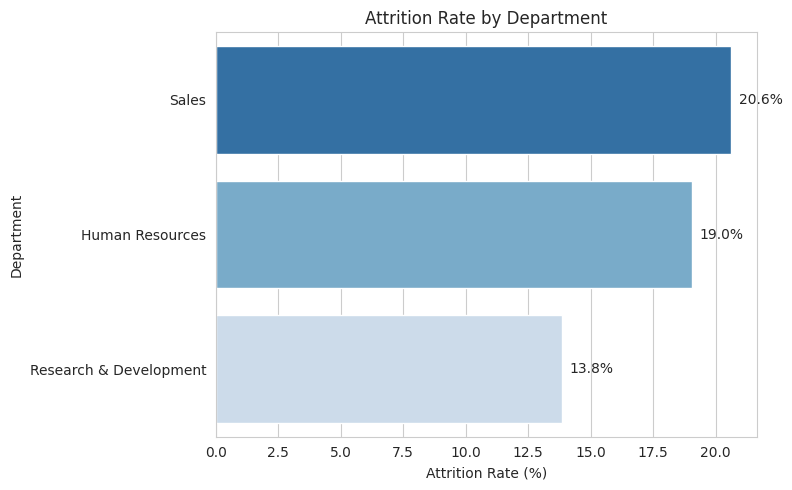

In [6]:
dept_attr = df.groupby("Department")["Attrition"].apply(lambda x: (x=="Yes").mean()*100).sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=dept_attr.values, y=dept_attr.index, ax=ax, palette="Blues_r", hue=dept_attr.index, legend=False)
ax.set_xlabel("Attrition Rate (%)")
ax.set_title("Attrition Rate by Department")
for i, v in enumerate(dept_attr.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.savefig("charts/02_attrition_by_department.png", dpi=120)
plt.show()

### 2.3 Attrition Rate by Job Role

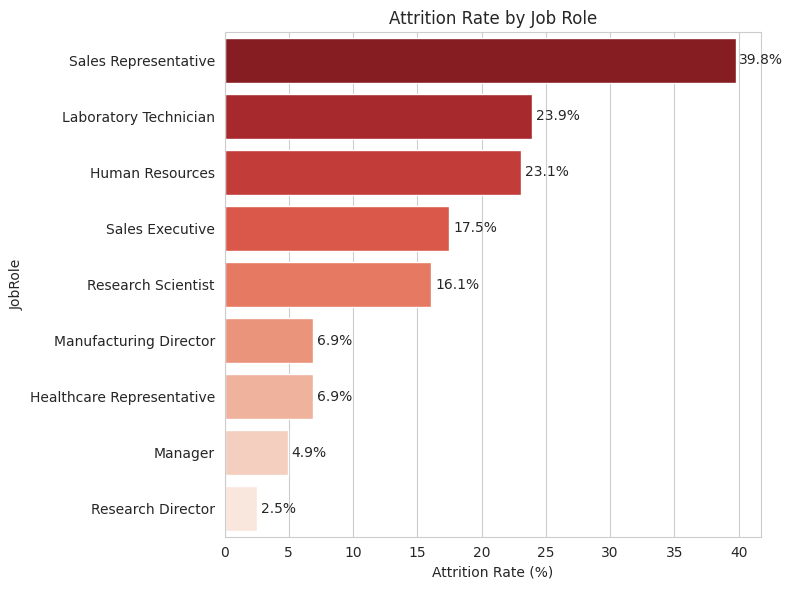

In [7]:
role_attr = df.groupby("JobRole")["Attrition"].apply(lambda x: (x=="Yes").mean()*100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(x=role_attr.values, y=role_attr.index, ax=ax, palette="Reds_r", hue=role_attr.index, legend=False)
ax.set_xlabel("Attrition Rate (%)")
ax.set_title("Attrition Rate by Job Role")
for i, v in enumerate(role_attr.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.savefig("charts/03_attrition_by_jobrole.png", dpi=120)
plt.show()

### 2.4 Does Overtime Drive Attrition?

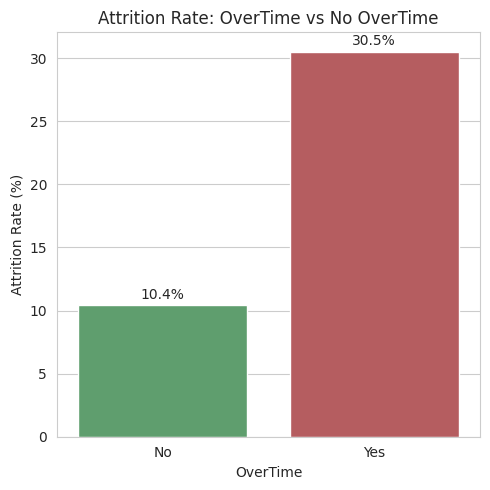

In [8]:
ot_attr = df.groupby("OverTime")["Attrition"].apply(lambda x: (x=="Yes").mean()*100)

fig, ax = plt.subplots(figsize=(5,5))
sns.barplot(x=ot_attr.index, y=ot_attr.values, ax=ax, palette=["#55A868", "#C44E52"], hue=ot_attr.index, legend=False)
ax.set_ylabel("Attrition Rate (%)")
ax.set_title("Attrition Rate: OverTime vs No OverTime")
for i, v in enumerate(ot_attr.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig("charts/04_attrition_by_overtime.png", dpi=120)
plt.show()

### 2.5 Age Distribution: Stayed vs Left

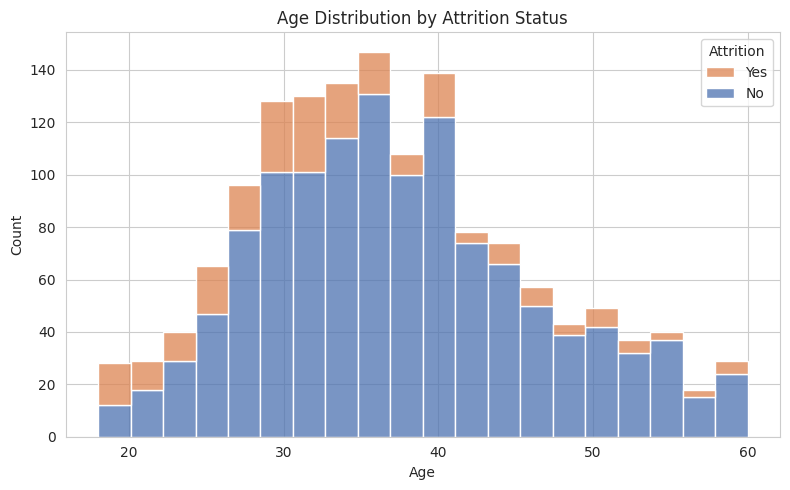

In [9]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="Age", hue="Attrition", multiple="stack", bins=20,
             palette={"No": "#4C72B0", "Yes": "#DD8452"}, ax=ax)
ax.set_title("Age Distribution by Attrition Status")
plt.tight_layout()
plt.savefig("charts/05_age_distribution.png", dpi=120)
plt.show()

### 2.6 Monthly Income vs Attrition

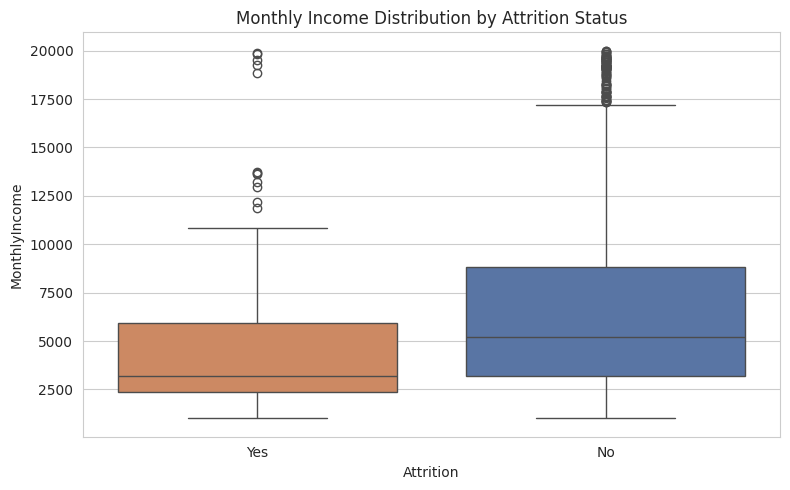

In [10]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", ax=ax,
            palette={"No": "#4C72B0", "Yes": "#DD8452"}, hue="Attrition", legend=False)
ax.set_title("Monthly Income Distribution by Attrition Status")
plt.tight_layout()
plt.savefig("charts/06_income_vs_attrition.png", dpi=120)
plt.show()

### 2.7 Job Satisfaction & Work-Life Balance vs Attrition

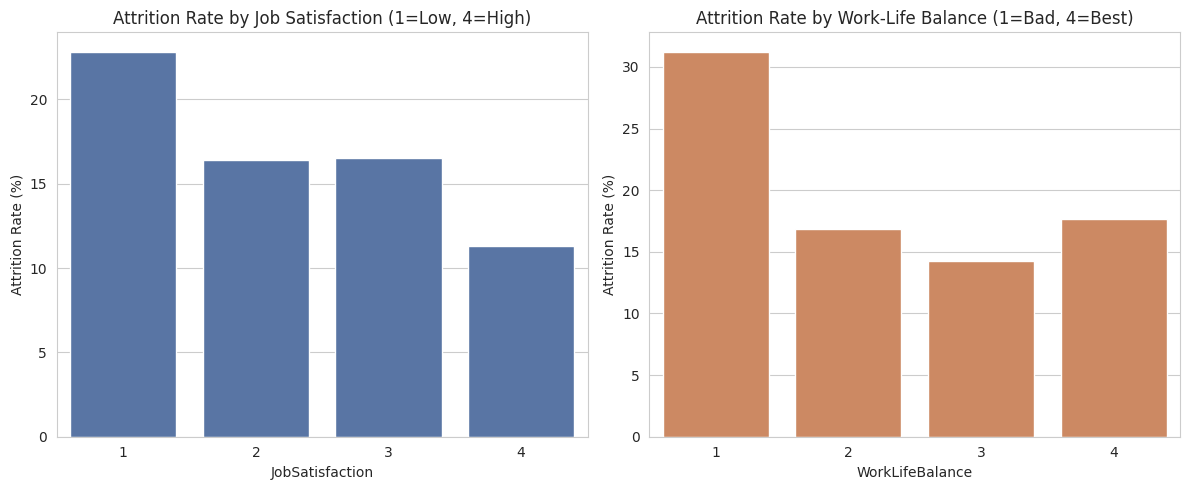

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sat = df.groupby("JobSatisfaction")["Attrition"].apply(lambda x: (x=="Yes").mean()*100)
sns.barplot(x=sat.index, y=sat.values, ax=axes[0], color="#4C72B0")
axes[0].set_title("Attrition Rate by Job Satisfaction (1=Low, 4=High)")
axes[0].set_ylabel("Attrition Rate (%)")

wlb = df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x=="Yes").mean()*100)
sns.barplot(x=wlb.index, y=wlb.values, ax=axes[1], color="#DD8452")
axes[1].set_title("Attrition Rate by Work-Life Balance (1=Bad, 4=Best)")
axes[1].set_ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.savefig("charts/07_satisfaction_wlb.png", dpi=120)
plt.show()

### 2.8 Tenure: Years at Company vs Attrition

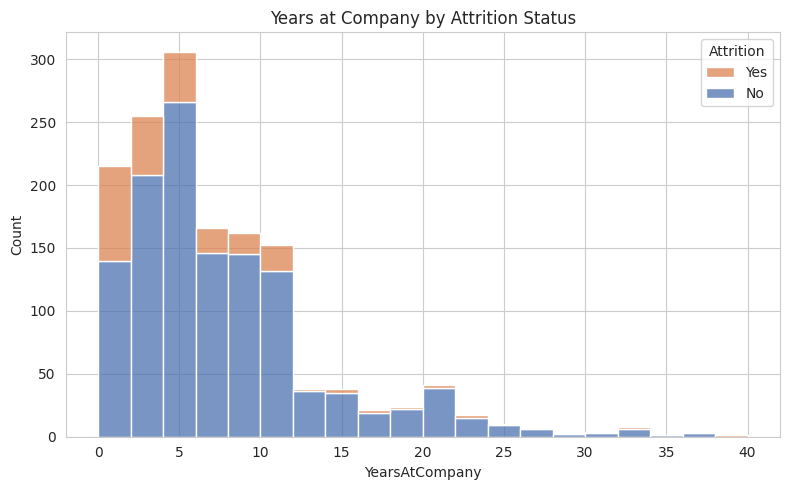

In [12]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="YearsAtCompany", hue="Attrition", multiple="stack", bins=20,
             palette={"No": "#4C72B0", "Yes": "#DD8452"}, ax=ax)
ax.set_title("Years at Company by Attrition Status")
plt.tight_layout()
plt.savefig("charts/08_tenure_distribution.png", dpi=120)
plt.show()

### 2.9 Correlation Heatmap (Numeric Features)
*OPTIONAL — useful for a portfolio screenshot, not required for the model itself.*

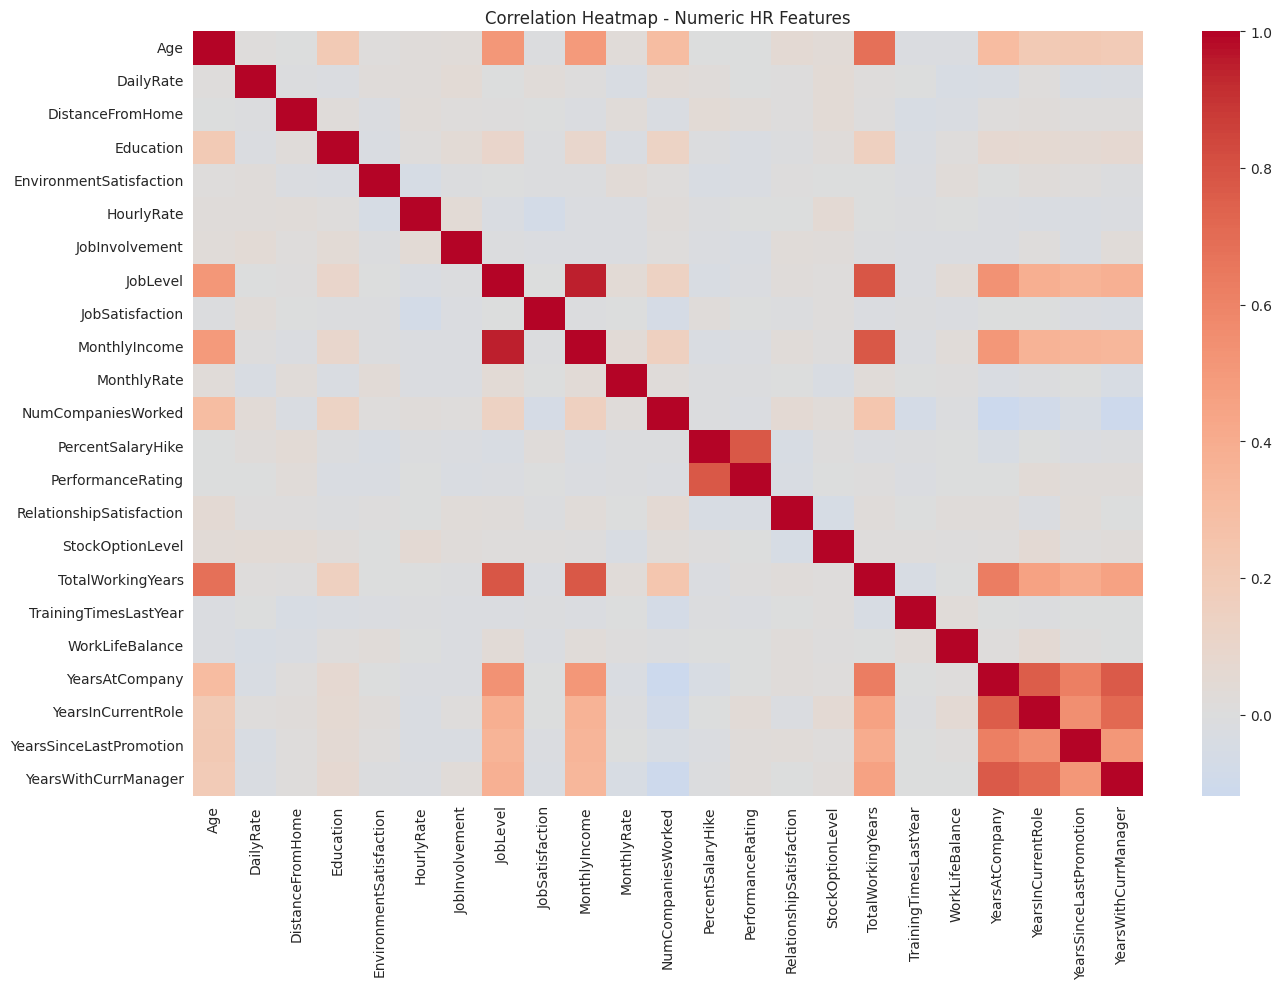

In [13]:
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=["EmployeeCount", "StandardHours", "EmployeeNumber"], errors="ignore")

fig, ax = plt.subplots(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, ax=ax, annot=False)
ax.set_title("Correlation Heatmap - Numeric HR Features")
plt.tight_layout()
plt.savefig("charts/09_correlation_heatmap.png", dpi=120)
plt.show()

### 📊 Dashboard Takeaways So Far
- Overall attrition is **~16%** — roughly 1 in 6 employees leaves.
- **Sales and HR departments**, and specifically **Sales Representatives**, show the highest attrition.
- **Overtime is one of the strongest visual drivers** — employees working overtime leave at a much higher rate.
- **Younger employees** and those with **fewer years at the company** leave more (early tenure risk).
- **Low job satisfaction** and **poor work-life balance** are both associated with higher attrition.
- Employees who leave tend to have **lower monthly income**.


## 3. Feature Engineering

We keep this deliberately simple and purposeful — every transformation has a clear reason:

1. **Drop constant / non-informative columns** — `EmployeeCount`, `StandardHours`, `Over18` never vary; `EmployeeNumber` is just an ID.
2. **Encode the target** (`Attrition`: Yes/No → 1/0).
3. **Encode categorical features** using Label Encoding — simple and sufficient for tree/linear models at this scale.
4. **One simple engineered feature**: `TenureGroup` — bucketing `YearsAtCompany` into early / mid / senior tenure, since the EDA showed early-tenure risk is a real pattern HR cares about.


In [14]:
data = df.copy()

# 1. Drop non-informative columns
drop_cols = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
data = data.drop(columns=drop_cols)

# 2. Encode target
data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})

# 3. Simple engineered feature: tenure bucket
def tenure_group(years):
    if years <= 2:
        return "0-2 (New)"
    elif years <= 5:
        return "3-5 (Established)"
    else:
        return "6+ (Senior)"

data["TenureGroup"] = data["YearsAtCompany"].apply(tenure_group)

print("New feature preview:")
data[["YearsAtCompany", "TenureGroup"]].head()

New feature preview:


,YearsAtCompany,TenureGroup
0,6,6+ (Senior)
1,10,6+ (Senior)
2,0,0-2 (New)
3,8,6+ (Senior)
4,2,0-2 (New)


In [15]:
categorical_cols = data.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

data.head()

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'TenureGroup']


/tmp/ipykernel_571/84657177.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include="object").columns.tolist()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureGroup
0,41,1,2,1102,2,1,2,1,2,0,94,3,2,7,4,2,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,2
1,49,0,1,279,1,8,1,1,3,1,61,2,2,6,2,1,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,2
2,37,1,2,1373,1,2,2,4,4,1,92,2,1,2,3,2,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,56,3,1,6,3,1,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,2
4,27,0,2,591,1,2,1,3,1,1,40,3,1,2,2,1,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0


## 4. Attrition Prediction Model

**Primary model: Logistic Regression.**
Chosen deliberately over more complex algorithms because:
- It's fast to train and fully explainable (coefficients = direction & strength of each factor's effect on attrition)
- HR stakeholders can trust and act on a model they can interpret
- With ~1,500 rows, a simple linear model is appropriate — there isn't enough data to justify deep learning or heavy tuning

Attrition is imbalanced (~84% stayed / ~16% left), so we use `class_weight="balanced"` and evaluate with metrics beyond accuracy (precision/recall/F1/ROC-AUC), since accuracy alone is misleading on imbalanced data.


In [16]:
X = data.drop(columns=["Attrition"])
y = data["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Attrition rate in train:", y_train.mean().round(3), " | test:", y_test.mean().round(3))

Train size: (1176, 31)  Test size: (294, 31)
Attrition rate in train: 0.162  | test: 0.16


In [17]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Performance ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

=== Logistic Regression Performance ===
Accuracy : 0.745
Precision: 0.354
Recall   : 0.723
F1 Score : 0.476
ROC-AUC  : 0.807

              precision    recall  f1-score   support

      Stayed       0.93      0.75      0.83       247
        Left       0.35      0.72      0.48        47

    accuracy                           0.74       294
   macro avg       0.64      0.74      0.65       294
weighted avg       0.84      0.74      0.77       294



**Why recall matters here:** In an attrition use case, missing an employee who is about to leave (a false negative) is usually costlier than flagging someone who was going to stay anyway (a false positive) — HR would rather over-flag a few extra people for a retention conversation than miss a real flight risk. That's why `class_weight="balanced"` is used to push the model toward catching more true leavers.

### 4.1 Confusion Matrix

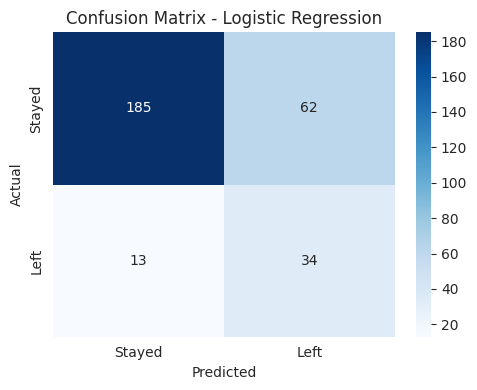

In [18]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed","Left"], yticklabels=["Stayed","Left"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.savefig("charts/10_confusion_matrix.png", dpi=120)
plt.show()

### 4.2 ROC Curve

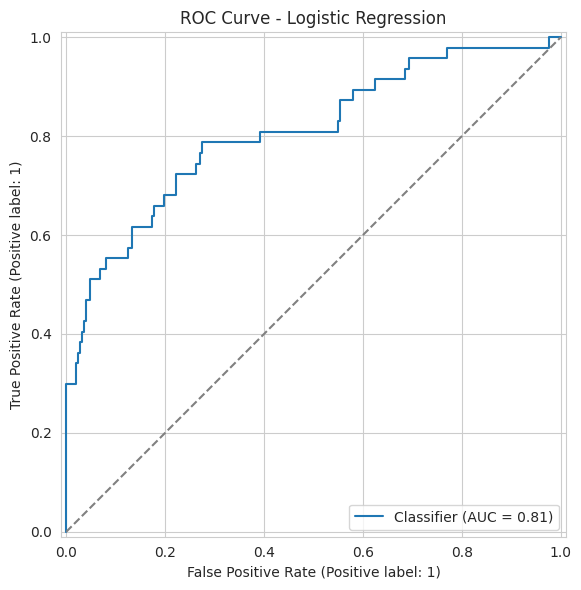

In [19]:
fig, ax = plt.subplots(figsize=(6,6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.plot([0,1],[0,1], linestyle="--", color="gray")
ax.set_title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.savefig("charts/11_roc_curve.png", dpi=120)
plt.show()

### 4.3 OPTIONAL: Random Forest Comparison
*This is optional — only run it if you have extra time and want a second model to compare against. It typically won't beat Logistic Regression's interpretability advantage for this use case, but it's a common portfolio addition.*

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Performance (Optional Comparison) ===")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.3f}")
print(f"Precision: {precision_score(y_test, rf_pred):.3f}")
print(f"Recall   : {recall_score(y_test, rf_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, rf_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_proba):.3f}")

=== Random Forest Performance (Optional Comparison) ===
Accuracy : 0.833
Precision: 0.472
Recall   : 0.362
F1 Score : 0.410
ROC-AUC  : 0.780


## 5. What Drives Attrition? (Model-Based Insights)

Using the Logistic Regression coefficients, we can directly read off which factors push attrition risk up or down. This is the key advantage of using an explainable model for an HR audience.


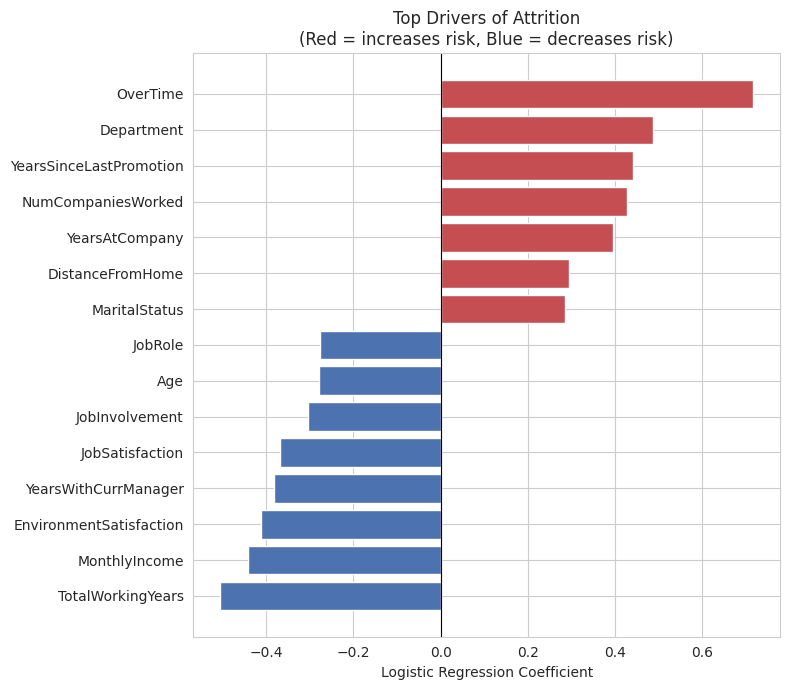

,Feature,Coefficient
18,OverTime,0.716971
23,TotalWorkingYears,-0.505645
3,Department,0.486709
15,MonthlyIncome,-0.442498
28,YearsSinceLastPromotion,0.441577
17,NumCompaniesWorked,0.426195
7,EnvironmentSatisfaction,-0.411392
26,YearsAtCompany,0.395698
29,YearsWithCurrManager,-0.381084
13,JobSatisfaction,-0.369029


In [21]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

top_n = 15
top_coef = coef_df.head(top_n).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(8,7))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in top_coef["Coefficient"]]
ax.barh(top_coef["Feature"], top_coef["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top Drivers of Attrition\n(Red = increases risk, Blue = decreases risk)")
ax.set_xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.savefig("charts/12_feature_importance.png", dpi=120)
plt.show()

coef_df.head(top_n)

**A note on reading these coefficients:** Categorical features here are Label Encoded (e.g. `Department`, `JobRole`), which assigns an arbitrary numeric order to categories — so their coefficient direction alone isn't meaningful in isolation; use the Section 2 bar charts for the actual per-category attrition rates instead. Also note that several tenure-related features (`YearsAtCompany`, `YearsWithCurrManager`, `YearsSinceLastPromotion`, `TotalWorkingYears`) are correlated with each other (see the correlation heatmap), which can cause a coefficient's sign to look counterintuitive once the others are controlled for. **Treat this chart as a ranking of overall influence, not as an isolated causal read of any single feature** — the raw EDA in Section 2 is the more reliable source for how each factor behaves on its own.

## 6. Strategic HR Insights & Recommendations

Combining the dashboard (Section 2) and the model drivers (Section 5):

**Top risk factors identified:**
1. **OverTime** — consistently one of the strongest predictors across both the raw dashboard and the model. Employees working overtime are significantly more likely to leave.
2. **Low tenure / early career stage** — new employees (0–2 years) are at higher flight risk than established or senior employees.
3. **Frequent business travel** — employees who travel frequently show elevated attrition.
4. **Low job satisfaction & poor work-life balance** — both self-reported satisfaction metrics correlate strongly with leaving.
5. **Lower monthly income relative to role/level** — compensation gaps appear to matter, especially early in tenure.
6. **Job role concentration** — Sales Representatives and Lab Technicians show disproportionately high attrition vs. other roles.

**Recommended actions for HR:**
- **Audit overtime policy** in high-attrition departments (Sales, HR) — chronic overtime is a controllable, fixable driver.
- **Strengthen onboarding & early-tenure engagement** (0–2 years) — this is the highest-risk window; structured check-ins and mentorship could help.
- **Review compensation bands** for roles/levels showing pay-related attrition, particularly Sales Representatives.
- **Use the model as a monthly screening tool** — score current employees monthly and flag the top 10–15% highest-risk individuals for a manager check-in, not as an automatic decision, but as a prompt for a human conversation.
- **Revisit travel requirements** for roles with frequent travel, where feasible, or add compensating support (travel stipends, flexible scheduling).

**Important caveat:** This model is a *decision-support tool*, not a verdict. A "high risk" prediction should trigger a supportive conversation with the employee, not any adverse action. Correlation here (e.g., overtime, travel) does not necessarily mean sole causation — other confounding factors (role, workload, personal circumstances) may contribute.


## 7. OPTIONAL: Save the Model for Reuse
*Skip this if you don't need to reuse the model outside this notebook — it's not required for the deliverables.*

In [22]:
import joblib

joblib.dump(log_reg, "attrition_logreg_model.pkl")
joblib.dump(scaler, "attrition_scaler.pkl")
print("Model and scaler saved.")

Model and scaler saved.


## 8. Summary

| Deliverable | Status |
|---|---|
| Attrition prediction model | ✅ Logistic Regression (explainable, class-balanced) |
| Key HR metrics dashboard | ✅ 9 core charts covering department, role, overtime, age, income, satisfaction, tenure |
| Strategic HR insights | ✅ Top 6 risk factors + 5 actionable recommendations |

This notebook is intentionally scoped to be completed in a single sitting (4–5 hours) while remaining portfolio-ready: every step has a stated purpose, the model is simple and explainable, and the insights are directly actionable for an HR audience.
